# Pricing the solver's settle-or-revert option

A winning solver can settle an order at whatever its routing is worth by the settlement deadline, or walk away and pay a penalty. With no penalty, the right to walk away is a free option, and free options distort bids. This notebook prices that option from the asset's short-term volatility and derives the penalty cap that follows.

**Payoffs.** Bid `s`, reference score `s_ref` (the counterfactual score without the winner), routing worth `R` at settlement:

| | settle | revert |
|---|---|---|
| no cap | `R - s_ref` | `-s_ref` |
| revert cost `C` | `R - s_ref` | `-C` |

All analysis is at the tie (`s = s_ref`), where settle profit reduces to the realized surplus.

**Contents.** Section 1 loads the tick data and estimates the volatility input with TSRV. Section 2 works a minimal three-state example: optimal bids, revert behavior, and why pricing the option to zero is equivalent to removing it. Section 3 prices the option over a settlement window in closed form and sets the revert-rate anchor. Sections 4-5 quantify bid inflation and the effect of the window length. Section 6 replays the auction cycle on the tick data without the normality assumption. Section 7 derives the cap formula and compares it to the benchmarks in play.

**Scope.** Voluntary, price-driven reverts only; reference score exogenous; driftless prices, so `C` is a break-even penalty rather than a hedging premium. Forced reverts (gas, outages, latency) sit on top and are out of scope.

In [1]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy.stats import norm
from scipy.optimize import brentq

T_EXCL = 10                    # headline settlement window (s); chain offsets from config later
T_GRID = [10, 30, 60]
Q_TARGET = 0.10                # walk-rate target; 5-15% is the working band
LONG_KEY = "LONGTAIL (synthetic, 5x DOGE)"

# ---- plotting: static plotly ----
pio.renderers.default = "png"
pio.renderers["png"].scale = 2
C_PAIR = {"ETHUSDC": "#2a78d6", "DOGEUSDT": "#eb6834", LONG_KEY: "#4a3aa7"}
GRAY, INK, GRID, SURF, AXIS = "#898781", "#0b0b0b", "#e1e0d9", "#fcfcfb", "#c3c2b7"

def style(fig, w=1050, h=430, title=None):
    fig.update_layout(width=w, height=h, template="none", paper_bgcolor=SURF, plot_bgcolor=SURF,
                      font=dict(size=13, color=INK), margin=dict(l=65, r=30, t=60, b=50),
                      legend=dict(bgcolor="rgba(0,0,0,0)"))
    if title: fig.update_layout(title=dict(text=title, font=dict(size=15)))
    fig.update_xaxes(gridcolor=GRID, zeroline=False, linecolor=AXIS)
    fig.update_yaxes(gridcolor=GRID, zeroline=False, linecolor=AXIS)
    return fig
print("params set")

params set


## 1. Data and the volatility input

Three days of Binance trades (May 1-3 2026) for ETHUSDC and DOGEUSDT, the dataset of `short_term_volatility_estimation.ipynb`, prepared the same way: duplicate trades dropped, bad prints removed with a rolling-median filter (3 MADs with a floor of max(2 ticks, 1 bp)).

Volatility is estimated with TSRV (two-scale realized variance) on 5-minute windows. Summing squared tick returns overstates variance because trade prices bounce between bid and ask; TSRV measures twice, once on the full tick grid (noise-dominated) and once averaged over sparse every-K-th-tick subgrids (mostly signal), and subtracts the scaled full-grid measure to cancel the noise. The per-second volatility used everywhere below is the median TSRV window converted to per-second units, in bps of order size.

A synthetic long-tail pair at 5x the DOGE volatility stands in for wide-spread assets until real data is added. All results scale linearly in these inputs, so their uncertainty (roughly 10-30% from the volatility notebook) passes through one-for-one.

In [2]:
import os, zipfile, pandas as pd

CACHE = "data/binance_ticks"   # ticks ship with the repo; run from the repo root
DAYS = ["2026-05-01", "2026-05-02", "2026-05-03"]
PAIRS_EMP = ["ETHUSDC", "DOGEUSDT"]
WINDOW_VOL_S = 300

def load_ticks(symbol):
    frames = []
    for d in DAYS:
        with zipfile.ZipFile(os.path.join(CACHE, f"{symbol}-aggTrades-{d}.zip")) as z:
            name = z.namelist()[0]
            hh = not z.open(name).read(64)[:1].isdigit()
            cols = ["aggId","price","qty","firstId","lastId","ts","isBuyerMaker","isBestMatch"]
            df = pd.read_csv(z.open(name), header=0 if hh else None, names=None if hh else cols)
            if hh:
                df.columns = [str(c).lower() for c in df.columns]
                tcol = [c for c in df.columns if "time" in c or c == "ts" or "transact" in c][0]
                df = df.rename(columns={tcol: "ts"})
            df = df[["price", "ts"]].astype({"ts": "int64", "price": float})
            unit = "us" if df["ts"].iloc[0] > 10**14 else "ms"
            df["t"] = pd.to_datetime(df["ts"], unit=unit, utc=True)
            frames.append(df[["t", "price"]])
    return pd.concat(frames).sort_values("t").reset_index(drop=True)

def clean(df, k=25, mad_mult=3.0, floor_ticks=2.0, floor_bps=1.0):
    df = df[(df.price > 0) & df.price.notna()].drop_duplicates(subset=["t", "price"]).copy()
    tick = np.median(np.diff(np.unique(np.sort(df.price.values))))
    med = df.price.rolling(2*k + 1, center=True, min_periods=k).median()
    mad = (df.price - med).abs().rolling(2*k + 1, center=True, min_periods=k).median()
    floor_abs = max(floor_ticks*tick, df.price.median()*floor_bps*1e-4)
    keep = ((df.price - med).abs() <= mad_mult*mad + floor_abs).fillna(True)
    return df[keep].set_index("t")

def rv_all(lp):
    r = np.diff(lp); return float(r @ r)

def tsrv(lp, K):
    # two-scale realized variance, finite-sample adjusted
    n = len(lp) - 1
    if n < 2*K + 2: return np.nan
    rva = np.mean([np.sum(np.diff(lp[k::K])**2) for k in range(K)])
    nbar = (n - K + 1)/K
    return max((rva - (nbar/n)*rv_all(lp))/(1 - nbar/n), 0.0)

TICKS = {p: clean(load_ticks(p)) for p in PAIRS_EMP}
SIGMA_1S = {}
for p in PAIRS_EMP:
    df = TICKS[p]
    t0, t1 = df.index.min().ceil("min"), df.index.max().floor("min")
    edges = pd.date_range(t0, t1, freq=f"{WINDOW_VOL_S}s")
    ivs = []
    for a, b in zip(edges[:-1], edges[1:]):
        w = df.loc[a:b]
        if len(w) < 200: continue
        Kw = max(2, min(int(round(len(w)*10.0/WINDOW_VOL_S)), (len(w) - 2)//2))
        ivs.append(tsrv(np.log(w.price.values), Kw))
    SIGMA_1S[p] = float(np.sqrt(np.median(ivs)/WINDOW_VOL_S)*1e4)   # bps per sqrt(second)
SIGMA_1S[LONG_KEY] = 5*SIGMA_1S["DOGEUSDT"]
sigma_T = lambda pair, T: SIGMA_1S[pair]*np.sqrt(T)

PX = {p: TICKS[p].price.resample("1s").last().ffill() for p in PAIRS_EMP}
for p in SIGMA_1S:
    print(f"{p:30s} TSRV per-second vol {SIGMA_1S[p]:.3f} bps/sqrt(s) | "
          f"vol over {T_EXCL}s = {sigma_T(p, T_EXCL):.2f} bps")

ETHUSDC                        TSRV per-second vol 0.357 bps/sqrt(s) | vol over 10s = 1.13 bps
DOGEUSDT                       TSRV per-second vol 0.787 bps/sqrt(s) | vol over 10s = 2.49 bps
LONGTAIL (synthetic, 5x DOGE)  TSRV per-second vol 3.937 bps/sqrt(s) | vol over 10s = 12.45 bps


## 2. A minimal example

Routing value `R` in {99, 100, 101} with equal probability, mean `mu` = 100. Settling earns `R - s_ref`; reverting costs `C`. Three properties drive everything that follows:
- Revert rule: settle iff `R - s_ref >= -C`, i.e. revert only when settling would lose more than the penalty.
- Equilibrium bid: the bid only decides which auctions are won, so the profit-maximizing bid sets the tie profit `E[max(R - s, -C)]` to zero. This holds for every `C`: behavior adapts to the penalty, so expected profit alone cannot pin the penalty down.
- Option value at a truthful bid: `OV(C) = E[(mu - C - R)+]`, the expected saving from walking away. A put payoff, positive whenever any revert region exists.

Solving for all `C` below: the optimal bid exceeds `mu` for every `C` under the never-revert level `C = mu - R_min = 1`, and `OV` reaches zero only at that level. A penalty large enough to zero the option value is a penalty under which reverting never happens, which is identical to having no cap at all. An interior penalty therefore needs a different anchor.

In [3]:
R_STATES = np.array([99.0, 100.0, 101.0]); MU = 100.0

def tie_profit(s, C):
    return np.mean(np.maximum(R_STATES - s, -C))

def opt_bid(C):
    hi = R_STATES.max()
    if tie_profit(hi, C) >= 0: return hi        # bid the edge of the support
    return brentq(lambda s: tie_profit(s, C), MU - 0.01, hi)

def revert_rate(s, C):
    return np.mean(R_STATES - s < -C - 1e-9)   # tolerance for the indifference knife edge

Cs = np.linspace(0, 1.5, 301)
sstar = np.array([opt_bid(C) for C in Cs])
rrate = np.array([revert_rate(s, C) for s, C in zip(sstar, Cs)])
ov = np.array([np.mean(np.maximum(MU - C - R_STATES, 0)) for C in Cs])

print("example check, s=100, s_ref=99.5: no-cap E =",
      round(np.mean(R_STATES - 99.5), 3), "| cap-0 E =", round(np.mean(np.maximum(R_STATES - 99.5, 0)), 3))
for C in [0.0, 0.2, 0.5, 1.0, 1.2]:
    s = opt_bid(C)
    print(f"C={C:.1f}: optimal bid {s:.2f} | revert rate {revert_rate(s, C):.0%} | "
          f"OV at truthful bid {np.mean(np.maximum(MU - C - R_STATES, 0)):.3f}")
print()
print("At C=0 the optimal bid is the edge of the distribution (101), reverting 2/3 of the time.")
print("OV hits zero only at C = mu - R_min = 1, exactly where reverting stops happening:")
print("option priced to zero = no-cap in disguise.")

example check, s=100, s_ref=99.5: no-cap E = 0.5 | cap-0 E = 0.667
C=0.0: optimal bid 101.00 | revert rate 67% | OV at truthful bid 0.333
C=0.2: optimal bid 100.60 | revert rate 67% | OV at truthful bid 0.267
C=0.5: optimal bid 100.25 | revert rate 33% | OV at truthful bid 0.167
C=1.0: optimal bid 100.00 | revert rate 0% | OV at truthful bid 0.000
C=1.2: optimal bid 100.00 | revert rate 0% | OV at truthful bid 0.000

At C=0 the optimal bid is the edge of the distribution (101), reverting 2/3 of the time.
OV hits zero only at C = mu - R_min = 1, exactly where reverting stops happening:
option priced to zero = no-cap in disguise.


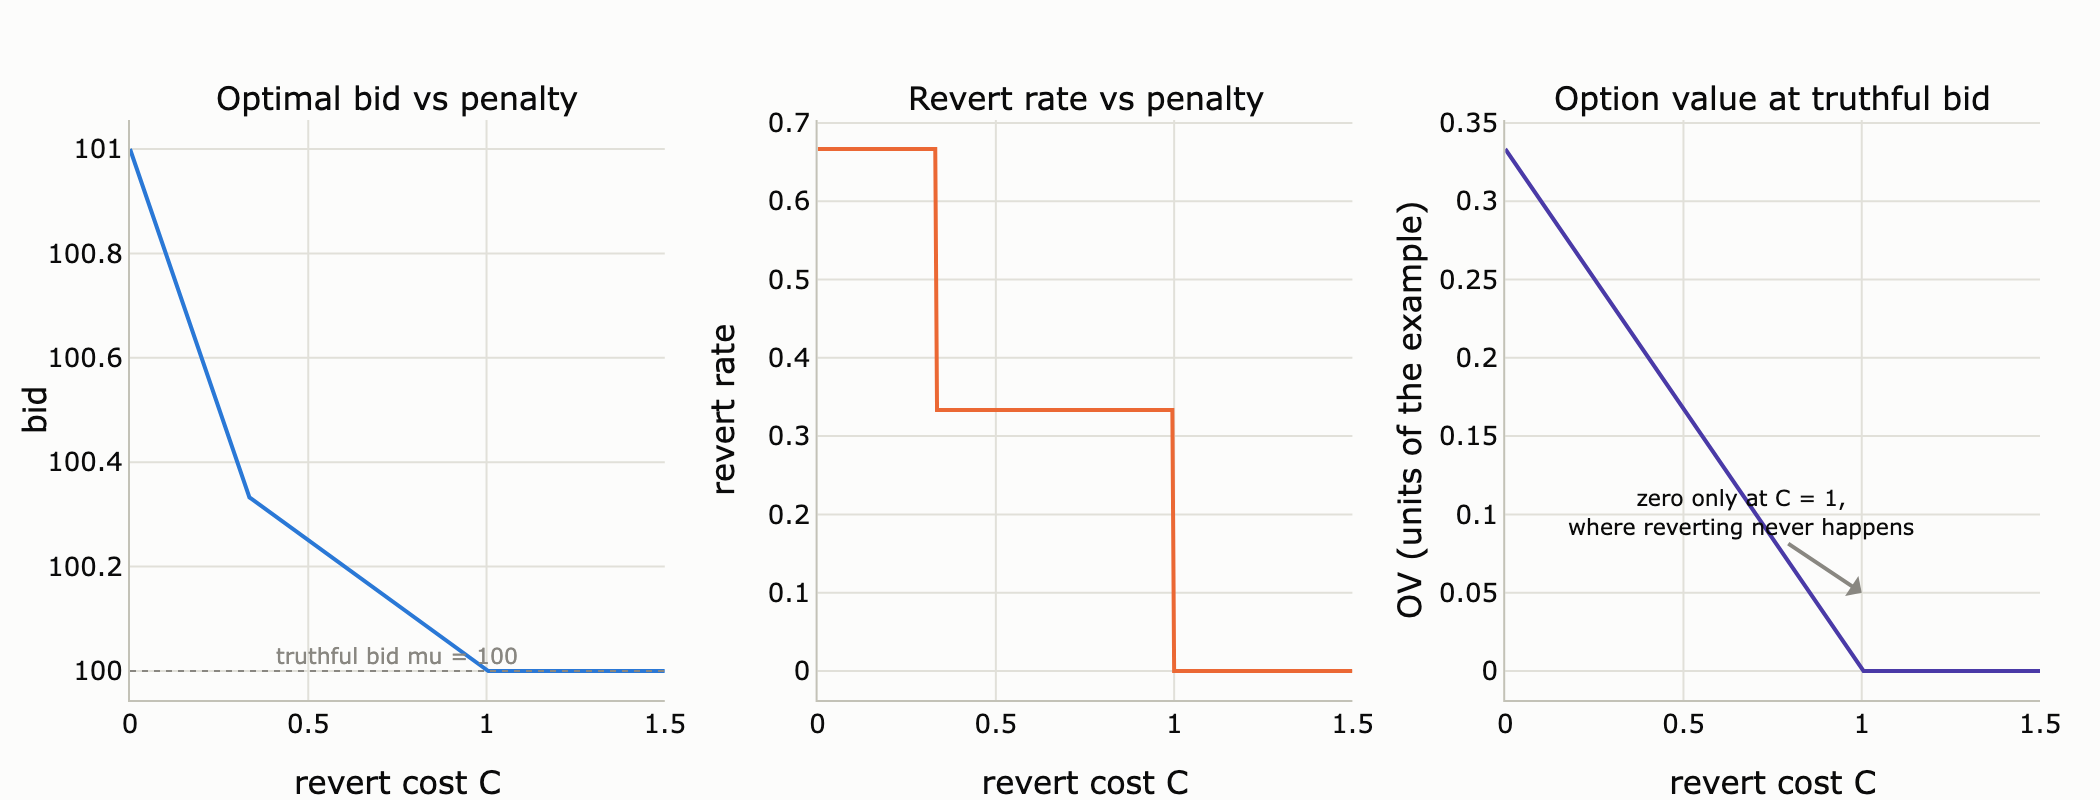

In [4]:
fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.08,
                    subplot_titles=("Optimal bid vs penalty", "Revert rate vs penalty",
                                    "Option value at truthful bid"))
fig.add_trace(go.Scatter(x=Cs, y=sstar, mode="lines", line=dict(color="#2a78d6", width=2),
                         showlegend=False), row=1, col=1)
fig.add_hline(y=MU, line=dict(color=GRAY, dash="dot", width=1), row=1, col=1)
fig.add_annotation(text="truthful bid mu = 100", x=0.75, y=MU, yanchor="bottom", showarrow=False,
                   font=dict(color=GRAY, size=11), row=1, col=1)
fig.add_trace(go.Scatter(x=Cs, y=rrate, mode="lines", line=dict(color="#eb6834", width=2),
                         showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(x=Cs, y=ov, mode="lines", line=dict(color="#4a3aa7", width=2),
                         showlegend=False), row=1, col=3)
fig.add_annotation(text="zero only at C = 1,<br>where reverting never happens",
                   x=1.0, y=0.05, ax=-60, ay=-40, showarrow=True, arrowcolor=GRAY,
                   font=dict(size=11), row=1, col=3)
for c in (1, 2, 3):
    fig.update_xaxes(title_text="revert cost C", row=1, col=c)
fig.update_yaxes(title_text="bid", row=1, col=1)
fig.update_yaxes(title_text="revert rate", row=1, col=2)
fig.update_yaxes(title_text="OV (units of the example)", row=1, col=3)
style(fig, h=400)
fig.show()

## 3. The option over a settlement window

Let the surplus over the reference, `Y = R - s_ref`, move drift-free with volatility `sigma_T = sigma_1s x sqrt(T)` over a window of `T` seconds (all in bps of order size). At the deadline the solver takes `max(Y, -C)`. With normal moves everything is closed form:

`OV(C) = sigma_T x phi(d) - C x Phi(-d)` and `P(revert) = Phi(-C / sigma_T)`, with `d = C / sigma_T` at the tie.

A binomial tree over the window reproduces these to 4 decimals, and its American version equals the European one: with no cost of waiting, settling early never pays (checked below). The closed forms carry the rest of the notebook.

Two results:
- `OV(0) = sigma_T / sqrt(2 pi)`, about 0.4x window vol, is the free option per order. `OV(C)` falls as the penalty rises but never reaches zero: some state is always bad enough that walking beats settling. Removing 99% of the option takes `C` above 2x window vol and leaves reverts at about 1%: the no-cap corner again, in continuous form.
- The penalty is therefore anchored on how much reverting the protocol tolerates. A walk-rate target `q` gives `C = sigma_T x z(1-q)`: 1.64x window vol for 5%, 1.28x for 10%, 1.04x for 15%. The 10% target is used below, with 5-15% as the working band.

In [5]:
def ev_closed(sig_T, delta, C):
    d = (delta + C)/sig_T
    return -C + (delta + C)*norm.cdf(d) + sig_T*norm.pdf(d)

def ov_closed(sig_T, delta, C):
    d = (delta + C)/sig_T
    return sig_T*norm.pdf(d) - (delta + C)*norm.cdf(-d)

def p_revert(sig_T, delta, C):
    return norm.cdf(-(delta + C)/sig_T)

def tree_value(sig_T, delta, C, N=400, american=False):
    dx = sig_T/np.sqrt(N)
    V = np.maximum(delta + (2*np.arange(N + 1) - N)*dx, -C)
    for n in range(N, 0, -1):
        V = 0.5*(V[1:] + V[:-1])
        if american:
            V = np.maximum(V, delta + (2*np.arange(n) - (n - 1))*dx)
    return float(V[0])

sT = sigma_T("DOGEUSDT", T_EXCL)
tv, av, cf = tree_value(sT, 0, 1), tree_value(sT, 0, 1, american=True), ev_closed(sT, 0, 1)
print(f"validation (DOGE, {T_EXCL}s, C=1): tree {tv:.4f} = closed form {cf:.4f} bps | "
      f"American - European = {av - tv:.1e} (no early-exercise value)")

validation (DOGE, 10s, C=1): tree 0.5718 = closed form 0.5723 bps | American - European = 0.0e+00 (no early-exercise value)


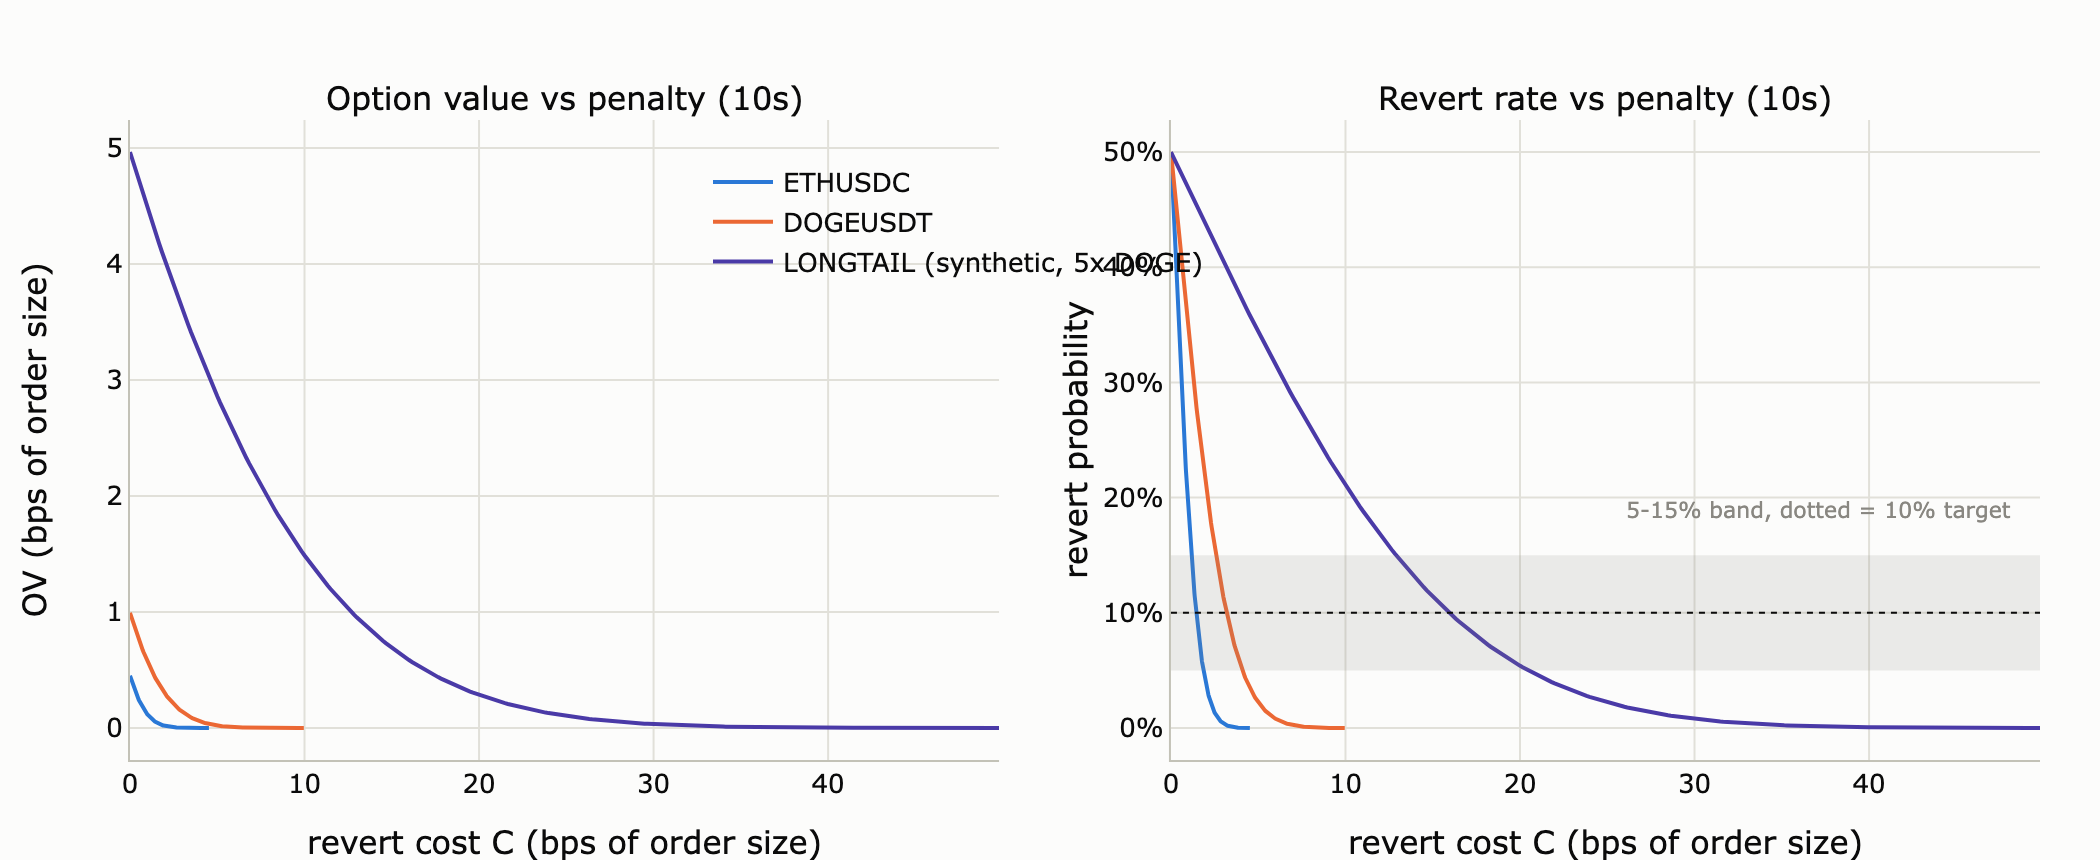

removing 99% of the option takes C = 2.27x window vol (same multiple for every pair), leaving reverts at 1.2%
revert-rate anchor at the 10% target: C = 1.28x window vol


In [6]:
EPS_FRAC = 0.01
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.09,
                    subplot_titles=(f"Option value vs penalty ({T_EXCL}s)",
                                    f"Revert rate vs penalty ({T_EXCL}s)"))
for pair, col in C_PAIR.items():
    sT = sigma_T(pair, T_EXCL)
    Cg = np.linspace(0, 4*sT, 300)
    fig.add_trace(go.Scatter(x=Cg, y=[ov_closed(sT, 0, C) for C in Cg], mode="lines",
                             line=dict(color=col, width=2), name=pair), row=1, col=1)
    fig.add_trace(go.Scatter(x=Cg, y=[p_revert(sT, 0, C) for C in Cg], mode="lines",
                             line=dict(color=col, width=2), showlegend=False), row=1, col=2)
fig.add_hrect(y0=0.05, y1=0.15, fillcolor="rgba(137,135,129,0.15)", line_width=0, row=1, col=2)
fig.add_hline(y=Q_TARGET, line=dict(color=INK, dash="dot", width=1), row=1, col=2)
fig.add_annotation(text="5-15% band, dotted = 10% target", x=0.97, xref="x2 domain", y=0.19,
                   xanchor="right", showarrow=False, font=dict(color=GRAY, size=11), row=1, col=2)
fig.update_xaxes(title_text="revert cost C (bps of order size)", row=1, col=1)
fig.update_xaxes(title_text="revert cost C (bps of order size)", row=1, col=2)
fig.update_yaxes(title_text="OV (bps of order size)", row=1, col=1)
fig.update_yaxes(title_text="revert probability", tickformat=".0%", row=1, col=2)
style(fig, h=430)
fig.update_layout(legend=dict(x=0.30, y=0.95))
fig.show()

sT = sigma_T("ETHUSDC", T_EXCL); ov0 = ov_closed(sT, 0, 0)
cstar = brentq(lambda C: ov_closed(sT, 0, C) - EPS_FRAC*ov0, 0, 8*sT)
print(f"removing 99% of the option takes C = {cstar/sT:.2f}x window vol "
      f"(same multiple for every pair), leaving reverts at {p_revert(sT, 0, cstar):.1%}")
print(f"revert-rate anchor at the {Q_TARGET:.0%} target: C = {norm.ppf(1-Q_TARGET):.2f}x window vol")

## 4. Bid inflation under a small penalty

The equilibrium bid solves zero-tie-profit, `E[max(R - s, -C)] = 0`. In vol units the solution is one curve for every asset:
- As `C` shrinks, the bid premium over fair value explodes; at `C` = 0 with unbounded moves there is no finite optimal bid (bid anything, revert almost always).
- As `C` grows, bids fall back to fair value, the no-cap behavior.
- Whatever optionality the penalty leaves unpriced gets bid into scores.

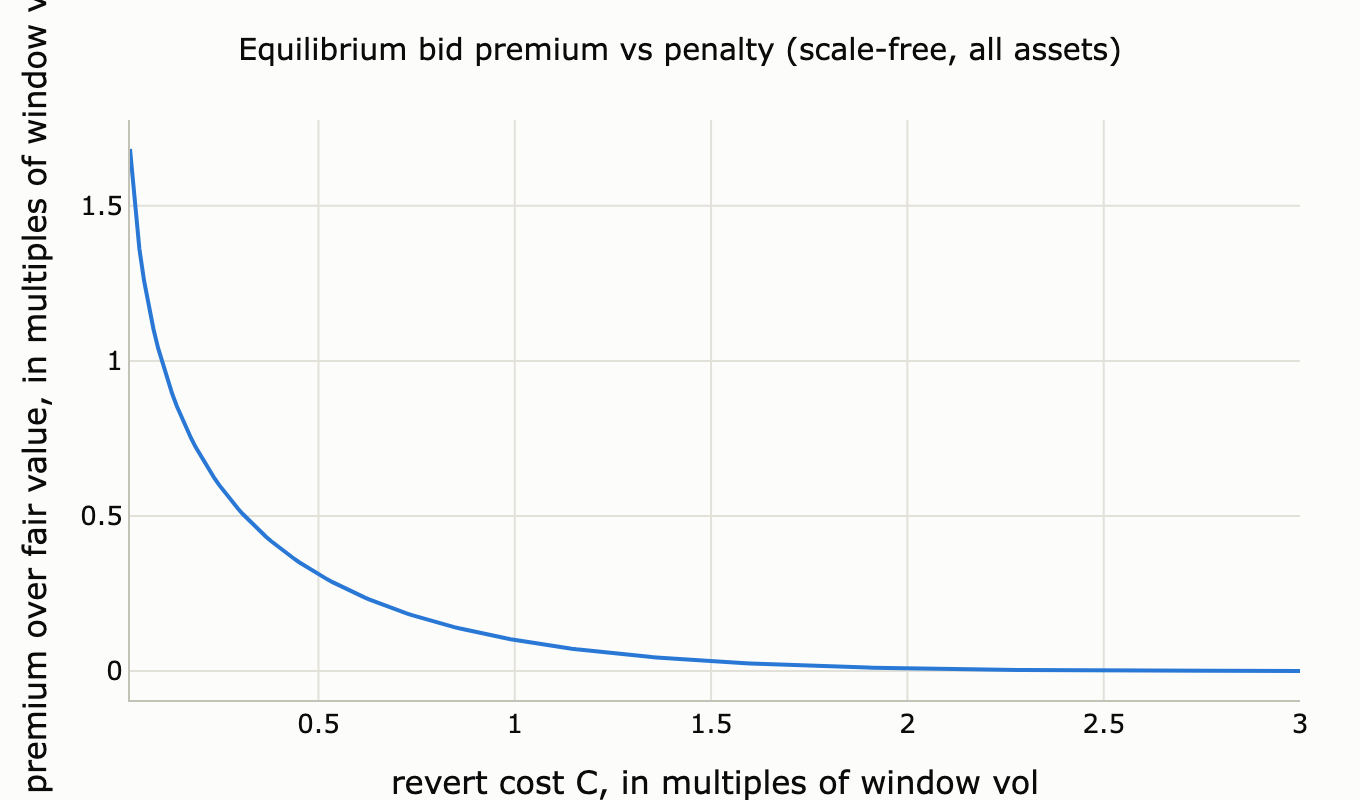

check: tie profit at the solved bid is -2.2e-16 (~0)
bid premium at C = 1 vol: 0.10 vols | at C = 2 vols: 0.009 vols


In [7]:
def bid_premium(C_over_vol):
    return brentq(lambda b: ev_closed(1.0, -b, C_over_vol), 0, 12)

Cg = np.linspace(0.02, 3, 250)
fig = go.Figure()
fig.add_trace(go.Scatter(x=Cg, y=[bid_premium(c) for c in Cg], mode="lines",
                         line=dict(color="#2a78d6", width=2), showlegend=False))
fig.update_xaxes(title="revert cost C, in multiples of window vol")
fig.update_yaxes(title="bid premium over fair value, in multiples of window vol")
style(fig, w=680, h=400, title="Equilibrium bid premium vs penalty (scale-free, all assets)")
fig.show()
print(f"check: tie profit at the solved bid is {ev_closed(1.0, -bid_premium(1.0), 1.0):.1e} (~0)")
print(f"bid premium at C = 1 vol: {bid_premium(1.0):.2f} vols | at C = 2 vols: {bid_premium(2.0):.3f} vols")

## 5. The window length prices the option too

Everything scales with `sigma_T = sigma_1s x sqrt(T)`: doubling the window multiplies the free option and the required penalty by sqrt(2). A penalty-free exclusivity window is not free; its length sets the size of the option handed to the winner, and a cap calibrated at one window must be re-scaled if the window changes.

In [8]:
print("free option OV(0) per order, bps of order size:")
print(f"{'pair':30s}" + "".join(f"  @ {T:3d}s" for T in T_GRID))
for pair in SIGMA_1S:
    print(f"{pair:30s}" + "".join(f"  {ov_closed(sigma_T(pair, T), 0, 0):5.2f}" for T in T_GRID))

free option OV(0) per order, bps of order size:
pair                            @  10s  @  30s  @  60s
ETHUSDC                          0.45   0.78   1.10
DOGEUSDT                         0.99   1.72   2.43
LONGTAIL (synthetic, 5x DOGE)    4.97   8.60  12.16


## 6. Empirical replay on the tick data

The closed forms assume normal moves. This section drops that assumption and replays the auction cycle on the tick data directly: the solver bids fair value (the mid) at the /solve moment and has `T` seconds to the settle deadline; the payoff per order is `max(price move over the window, -cap)`, in bps of order size. Sweeping the cap gives the two quantities that matter: the average payoff of participating and the share of windows in which the solver walks.

- Dotted curves: the normal model at the TSRV vol. Solid: the data, which adds bid-ask bounce, fat tails, and the coarse DOGE tick (~0.9 bps, the steps in its walk curve).
- The empirical multiple `k` is quoted against the TSRV vol, since that is the cap formula's input. The raw standard deviation of window moves runs higher (bounce plus tails) and is not the right denominator.
- With driftless prices the average payoff is positive at every cap; its size is the subsidy deliberately left to the winner.
- Three days spanning a weekend is one regime; `k` should be pinned down on 1-3 months of data. The /solve and /settle offsets are chain parameters; `T` is swept here.
- Hedging mid-window preserves the revert right, so under driftless prices it neither beats nor loses to waiting. The perfect-hindsight path maximum, printed below, is the unreachable ceiling; it grows with the window.

In [9]:
def windows_bps(px, T):
    v = px.values
    n = (len(v) - 1)//T
    p0 = v[: n*T: T].reshape(n, 1)
    paths = (v[: n*T].reshape(n, T)/p0 - 1.0)*1e4               # running move vs the bid moment
    end = (v[T: n*T + 1: T].reshape(n, 1)/p0 - 1.0)[:, 0]*1e4   # move at the settle deadline
    return paths, end

for p in PAIRS_EMP:
    _, end = windows_bps(PX[p], T_EXCL)
    print(f"{p}: {len(end):,} non-overlapping {T_EXCL}s windows | raw std {end.std():.2f} bps "
          f"vs TSRV vol {sigma_T(p, T_EXCL):.2f} bps (gap = bounce + tails)")

ETHUSDC: 25,919 non-overlapping 10s windows | raw std 1.62 bps vs TSRV vol 1.13 bps (gap = bounce + tails)
DOGEUSDT: 25,916 non-overlapping 10s windows | raw std 2.80 bps vs TSRV vol 2.49 bps (gap = bounce + tails)


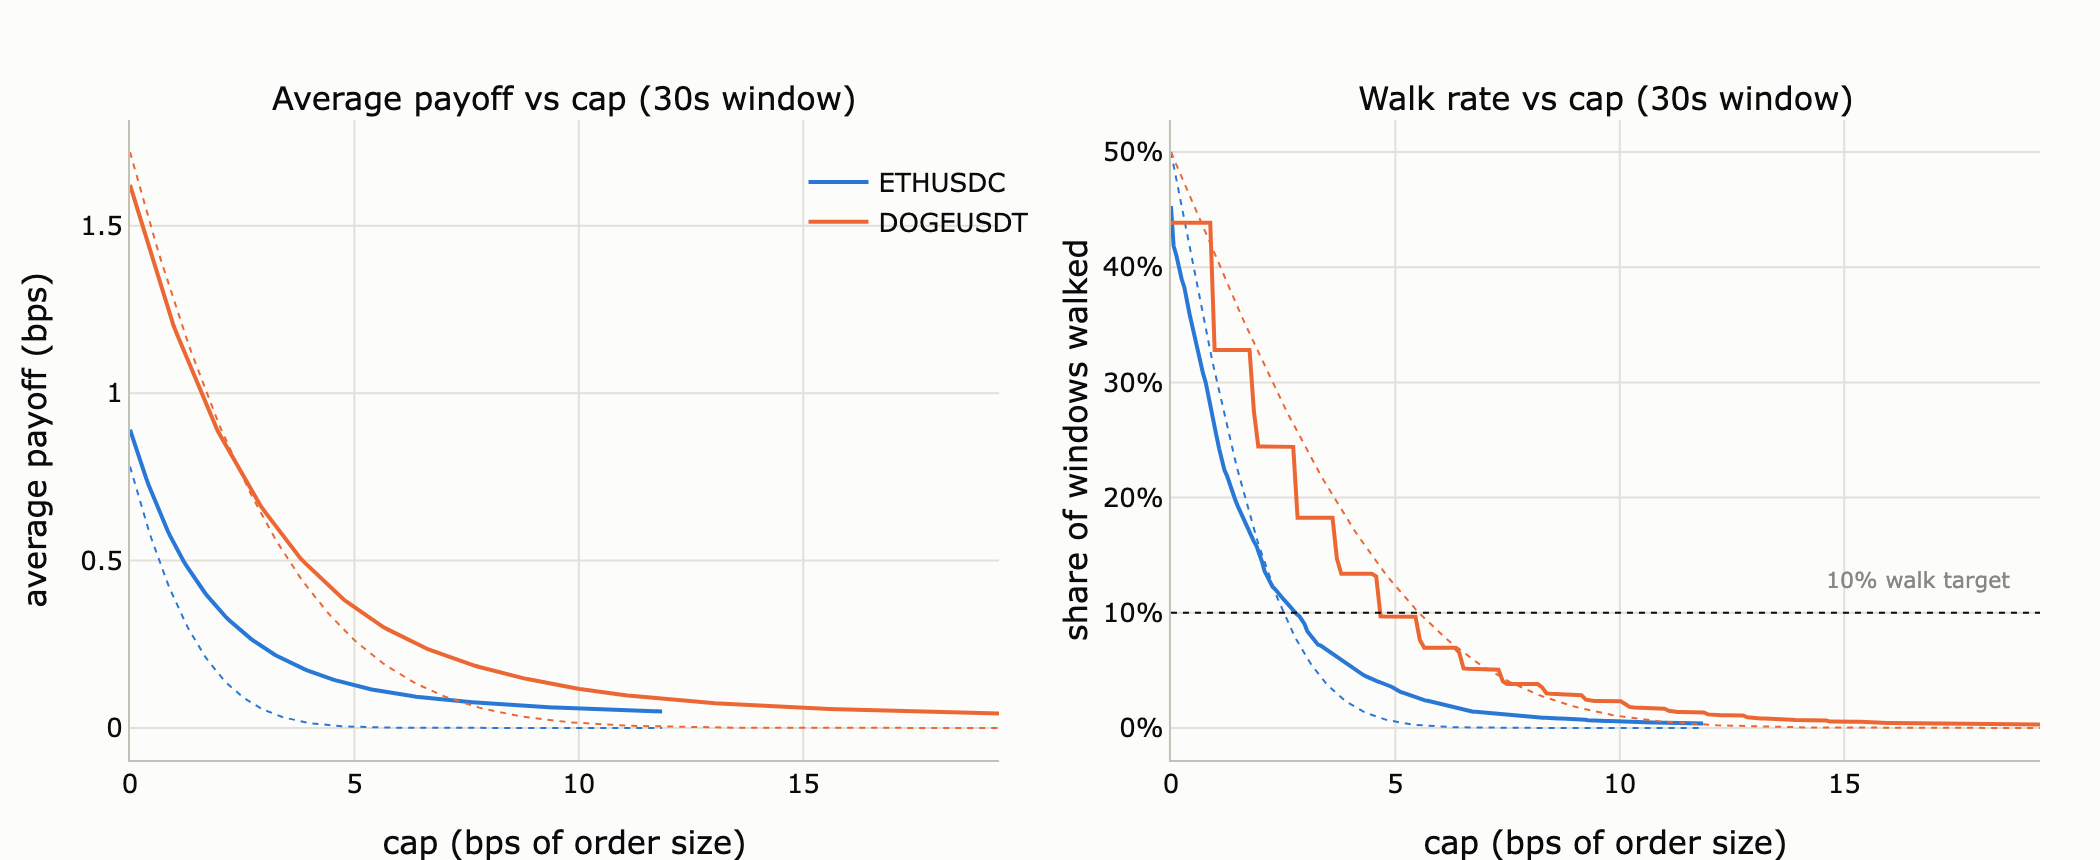

Solid: data. Dotted: normal model at the TSRV vol. The solid walk curves sit above the
dotted ones because real windows carry bounce and fat tails on top of diffusion.


In [10]:
T_EMP = 30
fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.09,
                    subplot_titles=(f"Average payoff vs cap ({T_EMP}s window)",
                                    f"Walk rate vs cap ({T_EMP}s window)"))
for pair in PAIRS_EMP:
    _, end = windows_bps(PX[pair], T_EMP)
    sT_r = sigma_T(pair, T_EMP)
    caps = np.linspace(0, 4*max(sT_r, end.std()), 200)
    col = C_PAIR[pair]
    fig.add_trace(go.Scatter(x=caps, y=[np.mean(np.maximum(end, -c)) for c in caps], mode="lines",
                             line=dict(color=col, width=2), name=pair), row=1, col=1)
    fig.add_trace(go.Scatter(x=caps, y=[ov_closed(sT_r, 0, c) for c in caps], mode="lines",
                             line=dict(color=col, width=1, dash="dot"), showlegend=False), row=1, col=1)
    fig.add_trace(go.Scatter(x=caps, y=[np.mean(end < -c) for c in caps], mode="lines",
                             line=dict(color=col, width=2), showlegend=False), row=1, col=2)
    fig.add_trace(go.Scatter(x=caps, y=[p_revert(sT_r, 0, c) for c in caps], mode="lines",
                             line=dict(color=col, width=1, dash="dot"), showlegend=False), row=1, col=2)
fig.add_hline(y=Q_TARGET, line=dict(color=INK, dash="dot", width=1), row=1, col=2)
fig.add_annotation(text="10% walk target", x=0.97, xref="x2 domain", y=0.13, xanchor="right",
                   showarrow=False, font=dict(color=GRAY, size=11), row=1, col=2)
fig.update_xaxes(title_text="cap (bps of order size)", row=1, col=1)
fig.update_xaxes(title_text="cap (bps of order size)", row=1, col=2)
fig.update_yaxes(title_text="average payoff (bps)", row=1, col=1)
fig.update_yaxes(title_text="share of windows walked", tickformat=".0%", row=1, col=2)
style(fig, h=430)
fig.update_layout(legend=dict(x=0.35, y=0.95))
fig.show()
print("Solid: data. Dotted: normal model at the TSRV vol. The solid walk curves sit above the")
print("dotted ones because real windows carry bounce and fat tails on top of diffusion.")

In [11]:
K_EMP = {}
print(f"empirical cap at the {Q_TARGET:.0%} walk target, and its multiple of the TSRV vol:")
print(f"{'pair':10s} {'T(s)':>5s} {'TSRV vol_T':>11s} {'raw std':>8s} {'cap@10%':>8s} "
      f"{'k = cap/vol':>12s} {'E[payoff]':>10s}")
for pair in PAIRS_EMP:
    K_EMP[pair] = {}
    for T in T_GRID:
        _, end = windows_bps(PX[pair], T)
        cap = float(-np.quantile(end, Q_TARGET))
        k = cap/sigma_T(pair, T)
        K_EMP[pair][T] = k
        print(f"{pair:10s} {T:5d} {sigma_T(pair, T):11.2f} {end.std():8.2f} {cap:8.2f} "
              f"{k:12.2f} {np.mean(np.maximum(end, -cap)):10.3f}")
kmin = min(min(d.values()) for d in K_EMP.values())
kmax = max(max(d.values()) for d in K_EMP.values())
print()
print(f"normal model: k = {norm.ppf(1-Q_TARGET):.2f}; this sample: {kmin:.2f}-{kmax:.2f}")
print("(bounce and fat tails on top of diffusion). Pin k down on 1-3 months of data.")

print()
print(f"hedging ceiling ({T_EMP}s window, cap at each pair's 10% level):")
for pair in PAIRS_EMP:
    paths, end = windows_bps(PX[pair], T_EMP)
    cap = float(-np.quantile(end, Q_TARGET))
    eur = np.mean(np.maximum(end, -cap))
    run_max = np.maximum(paths.max(axis=1), end)
    hind = np.mean(np.maximum(run_max, -cap))
    print(f"  {pair:10s} waiting (European): {eur:6.3f} bps | perfect hindsight: {hind:6.3f} bps "
          f"({hind/eur:.1f}x ceiling)")
print("A hedged solver keeps the revert right, so hedging preserves (not beats) the waiting value")
print("under driftless prices; the hindsight ceiling argues for keeping windows short.")

empirical cap at the 10% walk target, and its multiple of the TSRV vol:
pair        T(s)  TSRV vol_T  raw std  cap@10%  k = cap/vol  E[payoff]
ETHUSDC       10        1.13     1.62     1.31         1.16      0.158
ETHUSDC       30        1.96     2.96     2.77         1.42      0.258
ETHUSDC       60        2.77     4.37     4.00         1.44      0.384
DOGEUSDT      10        2.49     2.80     2.76         1.11      0.217
DOGEUSDT      30        4.31     4.84     4.64         1.08      0.395
DOGEUSDT      60        6.10     6.97     7.34         1.20      0.513

normal model: k = 1.28; this sample: 1.08-1.44
(bounce and fat tails on top of diffusion). Pin k down on 1-3 months of data.

hedging ceiling (30s window, cap at each pair's 10% level):
  ETHUSDC    waiting (European):  0.258 bps | perfect hindsight:  1.188 bps (4.6x ceiling)
  DOGEUSDT   waiting (European):  0.395 bps | perfect hindsight:  2.452 bps (6.2x ceiling)
A hedged solver keeps the revert right, so hedging preserves (

## 7. The cap formula

Derivation, from Section 3:
1. At the tie, the winner's payoff is `max(Y, -cap)`, with `Y` the surplus move over the settlement window, approximately normal with standard deviation `sigma_T = sigma_1s x sqrt(T)`.
2. The solver walks exactly when `Y < -cap`, so the walk probability is `Phi(-cap / sigma_T)`.
3. Fix the walk-rate target `q` and invert: `cap = z(1-q) x sigma_T`. Multiply by order size for currency terms. The tick replay replaces the normal quantile `z(1-q)` with its empirical counterpart `k` (Section 6).

> **cap(order) = k x sigma_1s(pair) x sqrt(T) x order size**

with `sigma_1s` the TSRV per-second vol (Section 1), `T` the settlement window from chain config, and `k` = 1.28 under the normal model at the 10% target, or the slightly higher empirical multiple printed in Section 6.

Read against the benchmarks in the table: a flat 2-3 bps cap roughly fits the majors at short windows but underprices a long-tail pair several-fold, and the current fixed USD caps mis-scale by construction (the same $21 is 21 bps of a $10k order and 0.2 bps of a $1M one). The option value remaining at this cap is a known, chosen subsidy: a small positive expected payoff that encourages participation.

**Caveats.** Diffusion-only: forced reverts sit on top, so observed revert rates will exceed the price-driven target. The realized penalty is `min(cap, s_ref)`, so in close auctions the reference score binds first. At-the-tie analysis with an exogenous reference score; solvers assumed to optimize. Volatility inputs carry their 10-30% band and pass through linearly.

**Next steps.** Pin `k` on 1-3 months of data and more pairs; a correlated-bucket fallback for pairs without CEX data; window values from chain config and logs; feed the capped penalty into the counterfactual re-pricing backtest.

In [12]:
K_NORMAL = norm.ppf(1 - Q_TARGET)
def k_for(pair, T):
    if pair in K_EMP and T in K_EMP[pair]: return K_EMP[pair][T], "empirical"
    if pair == LONG_KEY and T in K_EMP.get("DOGEUSDT", {}): return K_EMP["DOGEUSDT"][T], "DOGE proxy"
    return K_NORMAL, "normal"

print(f"cap(order) = k x sigma_1s x sqrt(T) x size, at the {Q_TARGET:.0%} walk target (bps of order size)")
print(f"{'pair':30s} {'T(s)':>5s} {'vol_T':>6s} {'k':>5s} {'k source':>11s} {'cap bps':>8s}")
for pair in SIGMA_1S:
    for T in T_GRID:
        k, srcname = k_for(pair, T)
        print(f"{pair:30s} {T:5d} {sigma_T(pair, T):6.2f} {k:5.2f} {srcname:>11s} "
              f"{k*sigma_T(pair, T):8.2f}")
print()
print("benchmarks: flat cap idea 2-3 bps | protocol fee ~2 bps | current fixed USD caps:")
for usd, name in [(21.15, "ethereum"), (24.72, "bnb"), (2.62, "polygon")]:
    print(f"  {name:9s} ${usd:5.2f}: $10k order = {usd/10_000*1e4:5.1f} bps | "
          f"$100k = {usd/100_000*1e4:5.2f} bps | $1M = {usd/1_000_000*1e4:5.3f} bps")

cap(order) = k x sigma_1s x sqrt(T) x size, at the 10% walk target (bps of order size)
pair                            T(s)  vol_T     k    k source  cap bps
ETHUSDC                           10   1.13  1.16   empirical     1.31
ETHUSDC                           30   1.96  1.42   empirical     2.77
ETHUSDC                           60   2.77  1.44   empirical     4.00
DOGEUSDT                          10   2.49  1.11   empirical     2.76
DOGEUSDT                          30   4.31  1.08   empirical     4.64
DOGEUSDT                          60   6.10  1.20   empirical     7.34
LONGTAIL (synthetic, 5x DOGE)     10  12.45  1.11  DOGE proxy    13.82
LONGTAIL (synthetic, 5x DOGE)     30  21.56  1.08  DOGE proxy    23.19
LONGTAIL (synthetic, 5x DOGE)     60  30.49  1.20  DOGE proxy    36.71

benchmarks: flat cap idea 2-3 bps | protocol fee ~2 bps | current fixed USD caps:
  ethereum  $21.15: $10k order =  21.1 bps | $100k =  2.11 bps | $1M = 0.211 bps
  bnb       $24.72: $10k order =  24.7 